# RNA-Seq Differential Gene Expression Analysis in Type 2 Diabetes

###Dataset
**GEO Accession:** GSE86468

###Research Question
Which genes are differentially expressed between pancreatic islets from individuals with Type 2 Diabetes and non-diabetic controls?



### 1. Import Required Libraries


In [2]:
import pandas as pd

### 2. Load the RNA-Seq Dataset

In [3]:
df = pd.read_csv("../data/GSE86468_GEO.bulk.islet.processed.data.RSEM.raw.expected.counts.csv.gz")

### 3. Explore the Dataset

In [4]:
# Display first five rows
df.head()      

,Unnamed: 0,baseline-03182015_S2,baseline-03272015_S8,baseline-05202015-Islet-15_S1,baseline-05222015-Islet-16_S6,baseline-09032015_S2,baseline-09102015_S7,baseline-10012015_S12,baseline-10292015_S17,Single-cell-bulk-03182015_S4,...,Single-cell-bulk-c1-10012015_S15,Single-cell-bulk-c1-10292015_S20,undissociated-c1-ctrl-09032015_S3,undissociated-c1-ctrl-09102015_S8,undissociated-c1-ctrl-10012015_S13,undissociated-c1-ctrl-10292015_S18,Untreated-Ctrl-03182015_S3,Untreated-Ctrl-03272015_S9,Untreated-Ctrl-05202015_S2,Untreated-Ctrl-05222015_S7
0,ENSG00000229483,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,ENSG00000232849,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,ENSG00000229558,0.00,0.00,1.00,1.00,0.00,0.00,2.00,1.00,0.00,...,1.00,1.00,1.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00
3,ENSG00000232977,30.17,24.52,2.16,20.48,4.14,3.26,9.61,16.66,19.63,...,17.78,15.51,12.07,11.86,13.56,5.29,36.86,30.20,14.40,24.14
4,ENSG00000227893,92.73,69.56,25.70,40.61,8.90,13.44,39.80,37.41,77.57,...,22.14,41.21,39.92,18.05,39.35,12.93,82.78,86.81,62.96,24.19


In [5]:
# Examine the Dataset Structure  (rows and column)
df.shape      

(26616, 25)

### Observation

- The dataset contains **26,616 rows (genes)** and **25 columns**.
- The first column contains **Ensembl Gene IDs**.
- The remaining **24 columns represent biological samples**.
- This matches the GEO study design (24 human pancreatic islet samples).

In [6]:
 # Display Column names
df.columns 

Index(['Unnamed: 0', 'baseline-03182015_S2', 'baseline-03272015_S8',
       'baseline-05202015-Islet-15_S1', 'baseline-05222015-Islet-16_S6',
       'baseline-09032015_S2', 'baseline-09102015_S7', 'baseline-10012015_S12',
       'baseline-10292015_S17', 'Single-cell-bulk-03182015_S4',
       'Single-cell-bulk-03272015_S10', 'Single-cell-bulk-05202015_S3',
       'Single-cell-bulk-05222015_S8', 'Single-cell-bulk-c1-09032015_S5',
       'Single-cell-bulk-c1-09102015_S10', 'Single-cell-bulk-c1-10012015_S15',
       'Single-cell-bulk-c1-10292015_S20', 'undissociated-c1-ctrl-09032015_S3',
       'undissociated-c1-ctrl-09102015_S8',
       'undissociated-c1-ctrl-10012015_S13',
       'undissociated-c1-ctrl-10292015_S18', 'Untreated-Ctrl-03182015_S3',
       'Untreated-Ctrl-03272015_S9', 'Untreated-Ctrl-05202015_S2',
       'Untreated-Ctrl-05222015_S7'],
      dtype='object')

#### Observation

- `df.columns` returns the names of all columns in the dataset.
- The first column is **Unnamed: 0**, which contains Ensembl Gene IDs.
- The remaining 24 columns represent biological samples.
- The sample names indicate different experimental groups, which will be confirmed using the GEO metadata before analysis.

In [7]:
# Display dataset information
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26616 entries, 0 to 26615
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          26616 non-null  object 
 1   baseline-03182015_S2                26616 non-null  float64
 2   baseline-03272015_S8                26616 non-null  float64
 3   baseline-05202015-Islet-15_S1       26616 non-null  float64
 4   baseline-05222015-Islet-16_S6       26616 non-null  float64
 5   baseline-09032015_S2                26616 non-null  float64
 6   baseline-09102015_S7                26616 non-null  float64
 7   baseline-10012015_S12               26616 non-null  float64
 8   baseline-10292015_S17               26616 non-null  float64
 9   Single-cell-bulk-03182015_S4        26616 non-null  float64
 10  Single-cell-bulk-03272015_S10       26616 non-null  float64
 11  Single-cell-bulk-05202015_S3        26616

#### Observation

- The dataset is stored as a pandas DataFrame.
- It contains **26,616 rows** (genes/annotated gene features) and **25 columns**.
- The first column (`Unnamed: 0`) is stored as **object**, indicating it contains Ensembl Gene IDs.
- The remaining **24 columns** are stored as **float64**, representing RNA-seq expression values.
- All columns contain **26,616 non-null values**, indicating there are **no missing values**.
- The dataset occupies approximately **5.1 MB** of memory.

In [8]:
 # Summary statistics
df.describe()  

,baseline-03182015_S2,baseline-03272015_S8,baseline-05202015-Islet-15_S1,baseline-05222015-Islet-16_S6,baseline-09032015_S2,baseline-09102015_S7,baseline-10012015_S12,baseline-10292015_S17,Single-cell-bulk-03182015_S4,Single-cell-bulk-03272015_S10,...,Single-cell-bulk-c1-10012015_S15,Single-cell-bulk-c1-10292015_S20,undissociated-c1-ctrl-09032015_S3,undissociated-c1-ctrl-09102015_S8,undissociated-c1-ctrl-10012015_S13,undissociated-c1-ctrl-10292015_S18,Untreated-Ctrl-03182015_S3,Untreated-Ctrl-03272015_S9,Untreated-Ctrl-05202015_S2,Untreated-Ctrl-05222015_S7
count,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,...,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04
mean,9.189660e+02,1.038578e+03,1.257176e+03,1.390437e+03,2.617403e+02,7.258878e+02,6.603078e+02,7.441654e+02,9.145276e+02,8.702011e+02,...,5.974552e+02,6.812339e+02,6.912506e+02,6.734500e+02,7.355426e+02,7.220239e+02,1.028756e+03,1.004173e+03,1.460081e+03,1.365470e+03
std,6.565712e+04,6.602598e+04,3.846117e+04,4.219669e+04,1.517929e+04,4.666619e+04,1.147264e+04,2.587075e+04,5.795922e+04,3.262654e+04,...,9.363116e+03,1.848145e+04,2.409659e+04,2.180168e+04,1.110997e+04,2.566040e+04,7.247892e+04,5.818858e+04,4.456461e+04,4.429039e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.200000e+01,1.500000e+01,7.000000e+00,2.600000e+01,4.000000e+00,1.076500e+01,1.700000e+01,1.699000e+01,2.300000e+01,3.700000e+01,...,2.411500e+01,2.323500e+01,1.226500e+01,1.400000e+01,2.000000e+01,1.600000e+01,1.525500e+01,1.900000e+01,9.140000e+00,2.400000e+01
75%,1.101375e+02,1.370100e+02,6.900000e+01,2.245300e+02,3.300000e+01,9.196000e+01,1.450025e+02,1.405475e+02,1.929825e+02,2.915125e+02,...,2.060000e+02,1.900000e+02,1.040000e+02,1.353125e+02,1.640000e+02,1.350000e+02,1.380000e+02,1.610000e+02,9.000000e+01,1.960000e+02
max,1.049688e+07,1.039546e+07,3.871330e+06,4.510982e+06,2.310745e+06,7.380508e+06,1.275880e+06,3.620577e+06,9.214173e+06,4.962086e+06,...,1.248398e+06,2.543317e+06,3.219735e+06,3.276156e+06,1.197739e+06,3.707490e+06,1.151307e+07,9.129486e+06,4.588218e+06,4.583842e+06


#### Observation

- `df.describe()` generated summary statistics for the **24 numeric sample columns**.
- The first column (`Unnamed: 0`) was excluded because it contains text (Ensembl Gene IDs).
- Each sample contains expression measurements for **26,616 gene features**.
- Many genes have expression values of **0**, indicating they were not detected in some samples.
- The maximum expression values are much larger than the median, suggesting a highly skewed distribution with a small number of very highly expressed genes.

### Understand the Experimental Design


## 4. Data Cleaning

In [9]:
### 4.1 Rename the Gene ID Column
# Rename the first column
df.rename(columns={"Unnamed: 0": "Gene_ID"}, inplace=True)
df.head()

,Gene_ID,baseline-03182015_S2,baseline-03272015_S8,baseline-05202015-Islet-15_S1,baseline-05222015-Islet-16_S6,baseline-09032015_S2,baseline-09102015_S7,baseline-10012015_S12,baseline-10292015_S17,Single-cell-bulk-03182015_S4,...,Single-cell-bulk-c1-10012015_S15,Single-cell-bulk-c1-10292015_S20,undissociated-c1-ctrl-09032015_S3,undissociated-c1-ctrl-09102015_S8,undissociated-c1-ctrl-10012015_S13,undissociated-c1-ctrl-10292015_S18,Untreated-Ctrl-03182015_S3,Untreated-Ctrl-03272015_S9,Untreated-Ctrl-05202015_S2,Untreated-Ctrl-05222015_S7
0,ENSG00000229483,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,ENSG00000232849,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,ENSG00000229558,0.00,0.00,1.00,1.00,0.00,0.00,2.00,1.00,0.00,...,1.00,1.00,1.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00
3,ENSG00000232977,30.17,24.52,2.16,20.48,4.14,3.26,9.61,16.66,19.63,...,17.78,15.51,12.07,11.86,13.56,5.29,36.86,30.20,14.40,24.14
4,ENSG00000227893,92.73,69.56,25.70,40.61,8.90,13.44,39.80,37.41,77.57,...,22.14,41.21,39.92,18.05,39.35,12.93,82.78,86.81,62.96,24.19


In [10]:
#4.2 Check for Missing Values
# Count missing values in each column
df.isnull().sum()

Gene_ID                               0
baseline-03182015_S2                  0
baseline-03272015_S8                  0
baseline-05202015-Islet-15_S1         0
baseline-05222015-Islet-16_S6         0
baseline-09032015_S2                  0
baseline-09102015_S7                  0
baseline-10012015_S12                 0
baseline-10292015_S17                 0
Single-cell-bulk-03182015_S4          0
Single-cell-bulk-03272015_S10         0
Single-cell-bulk-05202015_S3          0
Single-cell-bulk-05222015_S8          0
Single-cell-bulk-c1-09032015_S5       0
Single-cell-bulk-c1-09102015_S10      0
Single-cell-bulk-c1-10012015_S15      0
Single-cell-bulk-c1-10292015_S20      0
undissociated-c1-ctrl-09032015_S3     0
undissociated-c1-ctrl-09102015_S8     0
undissociated-c1-ctrl-10012015_S13    0
undissociated-c1-ctrl-10292015_S18    0
Untreated-Ctrl-03182015_S3            0
Untreated-Ctrl-03272015_S9            0
Untreated-Ctrl-05202015_S2            0
Untreated-Ctrl-05222015_S7            0


####Observation

- The dataset contains **no missing values**.
- Every column has **0 null values**, indicating that gene expression measurements are available for all genes and samples.
- Since there are no missing values, no imputation or removal of missing data is required.

In [11]:
### 4.3 Check for Duplicate Gene IDs
# Check for duplicate Gene IDs
df["Gene_ID"].duplicated().sum()

0

####Observation

- No duplicate Gene IDs were detected in the dataset.
- Each Gene_ID appears only once, indicating that every row represents a unique gene feature.
- Since there are no duplicate Gene IDs, no additional duplicate removal is required.

In [12]:
### 4.4 Set Gene_ID as the DataFrame Index
# Set Gene_ID as the row index
df.set_index("Gene_ID", inplace=True)

# Display the first five rows
df.head()

,baseline-03182015_S2,baseline-03272015_S8,baseline-05202015-Islet-15_S1,baseline-05222015-Islet-16_S6,baseline-09032015_S2,baseline-09102015_S7,baseline-10012015_S12,baseline-10292015_S17,Single-cell-bulk-03182015_S4,Single-cell-bulk-03272015_S10,...,Single-cell-bulk-c1-10012015_S15,Single-cell-bulk-c1-10292015_S20,undissociated-c1-ctrl-09032015_S3,undissociated-c1-ctrl-09102015_S8,undissociated-c1-ctrl-10012015_S13,undissociated-c1-ctrl-10292015_S18,Untreated-Ctrl-03182015_S3,Untreated-Ctrl-03272015_S9,Untreated-Ctrl-05202015_S2,Untreated-Ctrl-05222015_S7
Gene_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000229483,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ENSG00000232849,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ENSG00000229558,0.00,0.00,1.00,1.00,0.00,0.00,2.00,1.00,0.00,2.00,...,1.00,1.00,1.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00
ENSG00000232977,30.17,24.52,2.16,20.48,4.14,3.26,9.61,16.66,19.63,51.63,...,17.78,15.51,12.07,11.86,13.56,5.29,36.86,30.20,14.40,24.14
ENSG00000227893,92.73,69.56,25.70,40.61,8.90,13.44,39.80,37.41,77.57,128.97,...,22.14,41.21,39.92,18.05,39.35,12.93,82.78,86.81,62.96,24.19


In [13]:
### 4.5 Verify the Cleaned Dataset
# Check the dimensions of the cleaned dataset
df.shape

(26616, 24)

####Observation

- The cleaned dataset contains **26,616 genes** and **24 sample columns**.
- The `Gene_ID` column has been successfully converted into the DataFrame index.
- The dataset is now in the standard format used for RNA-seq gene expression analysis.

## 5. Exploratory Data Analysis (EDA)

In [14]:
### 5.1 Examine Gene Expression Distribution

In [15]:
df.dtypes
# Display overall expression statistics
df.describe()

,baseline-03182015_S2,baseline-03272015_S8,baseline-05202015-Islet-15_S1,baseline-05222015-Islet-16_S6,baseline-09032015_S2,baseline-09102015_S7,baseline-10012015_S12,baseline-10292015_S17,Single-cell-bulk-03182015_S4,Single-cell-bulk-03272015_S10,...,Single-cell-bulk-c1-10012015_S15,Single-cell-bulk-c1-10292015_S20,undissociated-c1-ctrl-09032015_S3,undissociated-c1-ctrl-09102015_S8,undissociated-c1-ctrl-10012015_S13,undissociated-c1-ctrl-10292015_S18,Untreated-Ctrl-03182015_S3,Untreated-Ctrl-03272015_S9,Untreated-Ctrl-05202015_S2,Untreated-Ctrl-05222015_S7
count,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,...,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04,2.661600e+04
mean,9.189660e+02,1.038578e+03,1.257176e+03,1.390437e+03,2.617403e+02,7.258878e+02,6.603078e+02,7.441654e+02,9.145276e+02,8.702011e+02,...,5.974552e+02,6.812339e+02,6.912506e+02,6.734500e+02,7.355426e+02,7.220239e+02,1.028756e+03,1.004173e+03,1.460081e+03,1.365470e+03
std,6.565712e+04,6.602598e+04,3.846117e+04,4.219669e+04,1.517929e+04,4.666619e+04,1.147264e+04,2.587075e+04,5.795922e+04,3.262654e+04,...,9.363116e+03,1.848145e+04,2.409659e+04,2.180168e+04,1.110997e+04,2.566040e+04,7.247892e+04,5.818858e+04,4.456461e+04,4.429039e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.200000e+01,1.500000e+01,7.000000e+00,2.600000e+01,4.000000e+00,1.076500e+01,1.700000e+01,1.699000e+01,2.300000e+01,3.700000e+01,...,2.411500e+01,2.323500e+01,1.226500e+01,1.400000e+01,2.000000e+01,1.600000e+01,1.525500e+01,1.900000e+01,9.140000e+00,2.400000e+01
75%,1.101375e+02,1.370100e+02,6.900000e+01,2.245300e+02,3.300000e+01,9.196000e+01,1.450025e+02,1.405475e+02,1.929825e+02,2.915125e+02,...,2.060000e+02,1.900000e+02,1.040000e+02,1.353125e+02,1.640000e+02,1.350000e+02,1.380000e+02,1.610000e+02,9.000000e+01,1.960000e+02
max,1.049688e+07,1.039546e+07,3.871330e+06,4.510982e+06,2.310745e+06,7.380508e+06,1.275880e+06,3.620577e+06,9.214173e+06,4.962086e+06,...,1.248398e+06,2.543317e+06,3.219735e+06,3.276156e+06,1.197739e+06,3.707490e+06,1.151307e+07,9.129486e+06,4.588218e+06,4.583842e+06


#### Observation

- All 24 samples contain gene expression values for 26,616 genes.
- Every sample has a minimum expression value of 0, indicating that many genes are not expressed.
- The median expression values are relatively low, while the maximum values are extremely high.
- In every sample, the mean is much larger than the median, indicating a right-skewed distribution.
- The expression patterns are broadly similar across all samples.

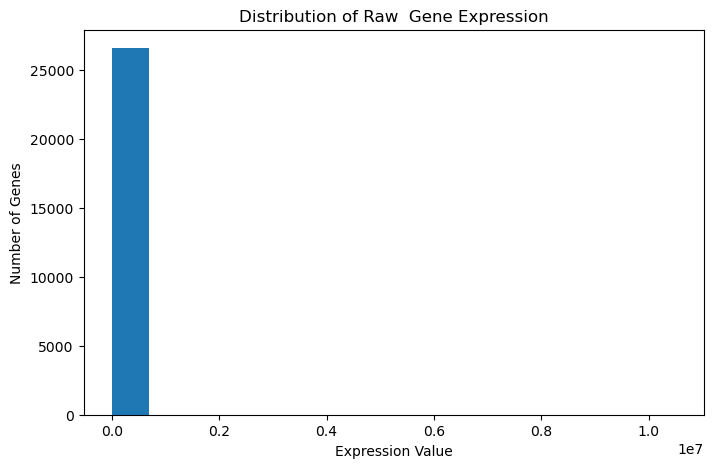

In [62]:
### 5.2 Visualize Gene Expression Distribution
import matplotlib.pyplot as plt
# Plot histogram for one sample
plt.figure(figsize=(8,5))

plt.hist(df["baseline-03182015_S2"], bins=15)

plt.title("Distribution of Raw  Gene Expression")
plt.xlabel("Expression Value")
plt.ylabel("Number of Genes")

plt.savefig("../figures/raw_gene_expression_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [17]:
### 5.3 Apply Log₂ Transformation
import numpy as np

# Apply log2 transformation to all expression values
df_log = np.log2(df + 1)

# Display the first 5 rows of the transformed dataset
df_log.head()


,baseline-03182015_S2,baseline-03272015_S8,baseline-05202015-Islet-15_S1,baseline-05222015-Islet-16_S6,baseline-09032015_S2,baseline-09102015_S7,baseline-10012015_S12,baseline-10292015_S17,Single-cell-bulk-03182015_S4,Single-cell-bulk-03272015_S10,...,Single-cell-bulk-c1-10012015_S15,Single-cell-bulk-c1-10292015_S20,undissociated-c1-ctrl-09032015_S3,undissociated-c1-ctrl-09102015_S8,undissociated-c1-ctrl-10012015_S13,undissociated-c1-ctrl-10292015_S18,Untreated-Ctrl-03182015_S3,Untreated-Ctrl-03272015_S9,Untreated-Ctrl-05202015_S2,Untreated-Ctrl-05222015_S7
Gene_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000229483,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000232849,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000229558,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.584963,1.000000,0.000000,1.584963,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.584963,0.000000,0.000000,0.000000,0.000000
ENSG00000232977,4.962086,4.673556,1.659925,4.424922,2.361768,2.090853,3.407353,4.142413,4.366672,5.717813,...,4.231125,4.045268,3.708187,3.684819,3.863938,2.653060,5.242603,4.963474,3.944858,4.651913
ENSG00000227893,6.550439,6.140779,4.738768,5.378858,3.307429,3.851999,5.350497,5.263410,6.295907,7.022035,...,4.532317,5.399513,5.354734,4.251719,5.334497,3.800123,6.388534,6.456313,5.999098,4.654779


####Observation

- A log₂ transformation was applied to all gene expression values.
- Adding 1 before the transformation prevents errors caused by zero expression values.
- The transformed values are on a much smaller scale while preserving the relative differences between genes.
- The transformed dataset is easier to visualize and is commonly used for exploratory analysis.

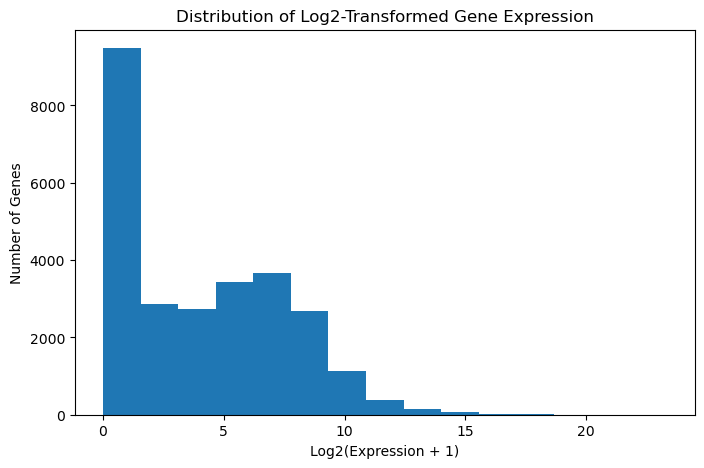

In [63]:
plt.figure(figsize=(8,5))

plt.hist(df_log["baseline-03182015_S2"], bins=15)

plt.title("Distribution of Log2-Transformed Gene Expression")
plt.xlabel("Log2(Expression + 1)")
plt.ylabel("Number of Genes")

plt.savefig("../figures/log2_gene_expression_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

####Observation

- After log₂ transformation, the distribution of gene expression values is much easier to visualize.
- Most genes have low to moderate expression levels.
- The extremely large expression values have been compressed.
- The data remain right-skewed, but the skewness is greatly reduced.
- Log₂ transformation improves visualization and prepares the data for downstream analysis.

In [19]:
### 5.4 Calculate Average Gene Expression
# Calculate the mean expression of each gene across all samples
gene_mean = df_log.mean(axis=1)

# Display the first 5 values
gene_mean.head()

Gene_ID
ENSG00000229483    0.000000
ENSG00000232849    0.000000
ENSG00000229558    0.722494
ENSG00000232977    3.976098
ENSG00000227893    5.313087
dtype: float64

In [20]:
### 5.5 Identify Highly Expressed Genes
# Display the top 10 most highly expressed genes
gene_mean.sort_values(ascending=False).head(10)

Gene_ID
ENSG00000115263    21.395535
ENSG00000118271    19.977795
ENSG00000254647    19.638376
ENSG00000087086    19.037613
ENSG00000115386    18.556372
ENSG00000198712    17.988332
ENSG00000157005    17.607113
ENSG00000251562    17.386530
ENSG00000100316    17.206229
ENSG00000156508    17.119707
dtype: float64

####Observation

- The genes were ranked according to their average log₂ expression across all 24 samples.
- The top 10 genes have the highest overall expression in the dataset.
- High expression does not necessarily mean that a gene is associated with Type 2 Diabetes.
- Differential expression analysis will later identify genes whose expression differs significantly between diabetic and non-diabetic samples.

##  Step 6. Differential Gene Expression Analysis

In [21]:
### 6.1 Extract Sample Names
# Get all sample names
sample_names = df_log.columns

# Display sample names
sample_names

Index(['baseline-03182015_S2', 'baseline-03272015_S8',
       'baseline-05202015-Islet-15_S1', 'baseline-05222015-Islet-16_S6',
       'baseline-09032015_S2', 'baseline-09102015_S7', 'baseline-10012015_S12',
       'baseline-10292015_S17', 'Single-cell-bulk-03182015_S4',
       'Single-cell-bulk-03272015_S10', 'Single-cell-bulk-05202015_S3',
       'Single-cell-bulk-05222015_S8', 'Single-cell-bulk-c1-09032015_S5',
       'Single-cell-bulk-c1-09102015_S10', 'Single-cell-bulk-c1-10012015_S15',
       'Single-cell-bulk-c1-10292015_S20', 'undissociated-c1-ctrl-09032015_S3',
       'undissociated-c1-ctrl-09102015_S8',
       'undissociated-c1-ctrl-10012015_S13',
       'undissociated-c1-ctrl-10292015_S18', 'Untreated-Ctrl-03182015_S3',
       'Untreated-Ctrl-03272015_S9', 'Untreated-Ctrl-05202015_S2',
       'Untreated-Ctrl-05222015_S7'],
      dtype='object')

In [22]:
# Count the number of samples
len(sample_names)

24

In [23]:
# Convert sample names into a DataFrame
sample_info = pd.DataFrame({
    "Sample": sample_names
})

sample_info

,Sample
0,baseline-03182015_S2
1,baseline-03272015_S8
2,baseline-05202015-Islet-15_S1
3,baseline-05222015-Islet-16_S6
4,baseline-09032015_S2
5,baseline-09102015_S7
6,baseline-10012015_S12
7,baseline-10292015_S17
8,Single-cell-bulk-03182015_S4
9,Single-cell-bulk-03272015_S10


In [24]:
### 6.2 Assign Sample Groups
# Assign each sample to its biological group
sample_info["Group"] = sample_info["Sample"].apply(
    lambda x: "Diabetic" if ("baseline" in x or "Single-cell-bulk" in x)
    else "Control"
)

sample_info

,Sample,Group
0,baseline-03182015_S2,Diabetic
1,baseline-03272015_S8,Diabetic
2,baseline-05202015-Islet-15_S1,Diabetic
3,baseline-05222015-Islet-16_S6,Diabetic
4,baseline-09032015_S2,Diabetic
5,baseline-09102015_S7,Diabetic
6,baseline-10012015_S12,Diabetic
7,baseline-10292015_S17,Diabetic
8,Single-cell-bulk-03182015_S4,Diabetic
9,Single-cell-bulk-03272015_S10,Diabetic


In [25]:
### 6.3 Verify Sample Groups
# Count the number of samples in each group
sample_info["Group"].value_counts()

Diabetic    16
Control      8
Name: Group, dtype: int64

In [26]:
# Display only control samples
sample_info[sample_info["Group"] == "Control"]

,Sample,Group
16,undissociated-c1-ctrl-09032015_S3,Control
17,undissociated-c1-ctrl-09102015_S8,Control
18,undissociated-c1-ctrl-10012015_S13,Control
19,undissociated-c1-ctrl-10292015_S18,Control
20,Untreated-Ctrl-03182015_S3,Control
21,Untreated-Ctrl-03272015_S9,Control
22,Untreated-Ctrl-05202015_S2,Control
23,Untreated-Ctrl-05222015_S7,Control


In [27]:
# Display only diabetic samples
sample_info[sample_info["Group"] == "Diabetic"]

,Sample,Group
0,baseline-03182015_S2,Diabetic
1,baseline-03272015_S8,Diabetic
2,baseline-05202015-Islet-15_S1,Diabetic
3,baseline-05222015-Islet-16_S6,Diabetic
4,baseline-09032015_S2,Diabetic
5,baseline-09102015_S7,Diabetic
6,baseline-10012015_S12,Diabetic
7,baseline-10292015_S17,Diabetic
8,Single-cell-bulk-03182015_S4,Diabetic
9,Single-cell-bulk-03272015_S10,Diabetic


In [28]:
sample_info["Group"].value_counts()

Diabetic    16
Control      8
Name: Group, dtype: int64

In [29]:
sample_info[sample_info["Group"] == "Control"]

,Sample,Group
16,undissociated-c1-ctrl-09032015_S3,Control
17,undissociated-c1-ctrl-09102015_S8,Control
18,undissociated-c1-ctrl-10012015_S13,Control
19,undissociated-c1-ctrl-10292015_S18,Control
20,Untreated-Ctrl-03182015_S3,Control
21,Untreated-Ctrl-03272015_S9,Control
22,Untreated-Ctrl-05202015_S2,Control
23,Untreated-Ctrl-05222015_S7,Control


In [30]:
### 6.4 Separate Diabetic and Control Samples

# Get the names of diabetic samples
diabetic_samples = sample_info[sample_info["Group"] == "Diabetic"]["Sample"]

# Get the names of control samples
control_samples = sample_info[sample_info["Group"] == "Control"]["Sample"]


In [31]:
sample_info["Group"] == "Diabetic"

0      True
1      True
2      True
3      True
4      True
5      True
6      True
7      True
8      True
9      True
10     True
11     True
12     True
13     True
14     True
15     True
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
Name: Group, dtype: bool

In [32]:
### 6.5 Create Diabetic and Control Expression Matrices
# Create a dataframe containing only diabetic samples
diabetic_data = df_log[diabetic_samples]

# Create a dataframe containing only control samples
control_data = df_log[control_samples]

In [33]:
diabetic_data.shape

(26616, 16)

In [34]:
control_data.shape

(26616, 8)

In [35]:
### 6.6 Perform Differential Gene Expression Analysis
from scipy.stats import ttest_ind
# Select the first gene
gene = diabetic_data.index[0]

# Diabetic expression values
diabetic_values = diabetic_data.loc[gene]

# Control expression values
control_values = control_data.loc[gene]

# Perform independent t-test
t_stat, p_value = ttest_ind(diabetic_values,
                            control_values)

print("Gene:", gene)
print("t-statistic:", t_stat)
print("p-value:", p_value)

Gene: ENSG00000229483
t-statistic: nan
p-value: nan


In [36]:
print(diabetic_values)

baseline-03182015_S2                0.0
baseline-03272015_S8                0.0
baseline-05202015-Islet-15_S1       0.0
baseline-05222015-Islet-16_S6       0.0
baseline-09032015_S2                0.0
baseline-09102015_S7                0.0
baseline-10012015_S12               0.0
baseline-10292015_S17               0.0
Single-cell-bulk-03182015_S4        0.0
Single-cell-bulk-03272015_S10       0.0
Single-cell-bulk-05202015_S3        0.0
Single-cell-bulk-05222015_S8        0.0
Single-cell-bulk-c1-09032015_S5     0.0
Single-cell-bulk-c1-09102015_S10    0.0
Single-cell-bulk-c1-10012015_S15    0.0
Single-cell-bulk-c1-10292015_S20    0.0
Name: ENSG00000229483, dtype: float64


In [37]:
print(control_values)

undissociated-c1-ctrl-09032015_S3     0.0
undissociated-c1-ctrl-09102015_S8     0.0
undissociated-c1-ctrl-10012015_S13    0.0
undissociated-c1-ctrl-10292015_S18    0.0
Untreated-Ctrl-03182015_S3            0.0
Untreated-Ctrl-03272015_S9            0.0
Untreated-Ctrl-05202015_S2            0.0
Untreated-Ctrl-05222015_S7            0.0
Name: ENSG00000229483, dtype: float64


In [38]:
gene = diabetic_data.index[100]

diabetic_values = diabetic_data.loc[gene]
control_values = control_data.loc[gene]

print(gene)

t_stat, p_value = ttest_ind(diabetic_values,
                            control_values)

print("t-statistic:", t_stat)
print("p-value:", p_value)

ENSG00000166157
t-statistic: 1.0810998555691553
p-value: 0.291361682412955


####Observation

- An independent two-sample t-test was performed for one gene.
- The t-statistic was 1.081, indicating only a small difference between the diabetic and control groups.
- The p-value was 0.291, which is greater than the significance level of 0.05.
- Therefore, this gene is not considered significantly differentially expressed.

In [39]:
### 6.6 Filter Genes with No Variation
# Calculate variance of each gene
gene_variance = df_log.var(axis=1)

# Display the first few variances
gene_variance.head()

Gene_ID
ENSG00000229483    0.000000
ENSG00000232849    0.000000
ENSG00000229558    0.595235
ENSG00000232977    0.985738
ENSG00000227893    0.970089
dtype: float64

In [40]:
### 6.7 Remove Genes with Zero Variance
# Keep only genes with variance greater than zero
df_filtered = df_log[gene_variance > 0]

# Display the dimensions of the filtered dataset
df_filtered.shape

(24950, 24)

####Observation

- Genes with zero variance were removed because they have identical expression values across all samples.
- These genes cannot be statistically compared using a t-test.
- The filtered dataset retains all 24 samples while reducing the number of genes.

In [41]:
### 6.8 Create Filtered Diabetic and Control Datasets
# Create filtered diabetic expression dataset
diabetic_data = df_filtered[diabetic_samples]

# Create filtered control expression dataset
control_data = df_filtered[control_samples]

# Check dimensions
print(diabetic_data.shape)
print(control_data.shape)

(24950, 16)
(24950, 8)


####Observation

- After removing genes with zero variance, **24,950 genes** remained for analysis.
- The filtered diabetic dataset contains **16 samples**.
- The filtered control dataset contains **8 samples**.
- Both datasets contain the same genes in the same row order, allowing gene-by-gene statistical comparison.

In [42]:
### 6.9 Perform a T-Test for Every Gene
# Create an empty list to store the results
results = []

# Perform a t-test for each gene
for gene in diabetic_data.index:
    
    # Get expression values for the current gene
    diabetic_values = diabetic_data.loc[gene]
    control_values = control_data.loc[gene]
    
    # Perform Welch's independent two-sample t-test
    t_stat, p_value = ttest_ind(
        diabetic_values,
        control_values,
        equal_var=False
    )
    
    # Save the result for the current gene
    results.append({
        "Gene_ID": gene,
        "t_statistic": t_stat,
        "p_value": p_value
    })
    
# Convert the results list into a DataFrame
results_df = pd.DataFrame(results)

# Display the first five results
results_df.head()

,Gene_ID,t_statistic,p_value
0,ENSG00000229558,1.349134,0.194587
1,ENSG00000232977,-0.423407,0.677040
2,ENSG00000227893,0.115262,0.909814
3,ENSG00000238230,2.166646,0.046774
4,ENSG00000260962,2.110898,0.051978


####Observation

- A Welch's independent two-sample t-test was performed for every gene.
- For each gene, the analysis produced a t-statistic and a p-value.
- Because thousands of statistical tests were performed simultaneously, the raw p-values must be adjusted to control the False Discovery Rate (FDR).

In [43]:
### 6.10 Adjust P-values Using the Benjamini-Hochberg Method
from statsmodels.stats.multitest import multipletests
# Adjust p-values using the Benjamini-Hochberg method
results_df["Adjusted_p_value"] = multipletests(
    results_df["p_value"],
    method="fdr_bh"
)[1]

results_df["p_value"]

0        0.194587
1        0.677040
2        0.909814
3        0.046774
4        0.051978
           ...   
24945    0.959348
24946    0.837633
24947    0.490951
24948    0.521116
24949    0.432473
Name: p_value, Length: 24950, dtype: float64

In [44]:
multiple_test_result = multipletests(
    results_df["p_value"],
    method="fdr_bh"
)
type(multiple_test_result)
len(multiple_test_result)
type(multiple_test_result[0])

numpy.ndarray

In [45]:
multiple_test_result[0][:10]

array([False, False, False, False, False, False, False, False, False,
       False])

In [46]:
type(multiple_test_result[1])

numpy.ndarray

In [47]:
multiple_test_result[1][:10]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [48]:
results_df["Adjusted_p_value"] = multiple_test_result[1]
results_df.head()

,Gene_ID,t_statistic,p_value,Adjusted_p_value
0,ENSG00000229558,1.349134,0.194587,1.0
1,ENSG00000232977,-0.423407,0.677040,1.0
2,ENSG00000227893,0.115262,0.909814,1.0
3,ENSG00000238230,2.166646,0.046774,1.0
4,ENSG00000260962,2.110898,0.051978,1.0


In [49]:
results_df["Adjusted_p_value"].min()

1.0

In [50]:
results_df["p_value"].min()

0.0001001373650313748

In [51]:
multiple_test_result

(array([False, False, False, ..., False, False, False]),
 array([1., 1., 1., ..., 1., 1., 1.]),
 2.0558413491578165e-06,
 2.004008016032064e-06)

In [52]:
results_df.sort_values("p_value").head(10)

,Gene_ID,t_statistic,p_value,Adjusted_p_value
4912,ENSG00000167080,4.735796,0.000100,1.0
1592,ENSG00000258909,4.039090,0.000570,1.0
9356,ENSG00000249099,4.084389,0.000767,1.0
7747,ENSG00000225996,3.737165,0.001155,1.0
108,ENSG00000228886,3.677430,0.001414,1.0
5044,ENSG00000260468,3.872983,0.001502,1.0
5710,ENSG00000267457,3.752935,0.001919,1.0
12388,ENSG00000007001,3.721858,0.002045,1.0
19995,ENSG00000155269,3.696672,0.002154,1.0
4457,ENSG00000235538,3.399589,0.002581,1.0


In [53]:
# Store the smallest raw p-value
smallest_p = results_df["p_value"].min()

# Multiply it by the number of genes tested
smallest_p * len(results_df)

2.4984272575328013

In [54]:
# Select genes with adjusted p-value less than 0.05
significant_genes = results_df[
    results_df["Adjusted_p_value"] < 0.05
]
significant_genes.head()
# Count the number of significant genes
len(significant_genes)

0

Welch's t-test → computes raw p-values.
Benjamini–Hochberg → adjusts those p-values.
Adjusted p-values → used to decide statistical significance.
### Observation
- Genes with an adjusted p-value < 0.05 were identified as statistically significant after applying the Benjamini–Hochberg (BH) multiple testing correction.
- In this analysis, no genes satisfied the significance criterion (Adjusted p-value < 0.05).
- The total number of significant genes identified was 0.
### Interpretation
- No statistically significant differentially expressed genes were detected between the diabetic and control groups after applying the Benjamini–Hochberg (BH) multiple testing correction to the raw p-values obtained from Welch's t-test.
- The BH correction was applied because approximately 24,950 genes were tested simultaneously, increasing the likelihood of false positive results. BH adjusts the raw p-values to control the False Discovery Rate (FDR).
- This result may be influenced by the relatively small sample size (16 diabetic and 8 control samples), the large number of genes tested, and the conservative nature of FDR correction.
- This analysis used Welch's t-test for educational purposes. In RNA-seq studies, specialized methods such as DESeq2, edgeR, or limma-voom are generally preferred because they are specifically designed for count-based gene expression data.


In [55]:
# Calculate the mean expression of each gene in diabetic samples
diabetic_mean = diabetic_data.mean(axis=1)
diabetic_mean.head()

Gene_ID
ENSG00000229558    0.859680
ENSG00000232977    3.919594
ENSG00000227893    5.329642
ENSG00000238230    0.286560
ENSG00000260962    0.349060
dtype: float64

In [56]:
# Calculate the mean expression of each gene in control samples
control_mean = control_data.mean(axis=1)
control_mean.head()

Gene_ID
ENSG00000229558    0.448120
ENSG00000232977    4.089107
ENSG00000227893    5.279975
ENSG00000238230    0.000000
ENSG00000260962    0.000000
dtype: float64

In [57]:
# Calculate log2 fold change for each gene
log2_fold_change = np.log2(
    (diabetic_mean + 1) / (control_mean + 1)
)

# Display the first five values
log2_fold_change.head()

Gene_ID
ENSG00000229558    0.360873
ENSG00000232977   -0.048873
ENSG00000227893    0.011365
ENSG00000238230    0.363519
ENSG00000260962    0.431955
dtype: float64

### Observation
- The log₂ fold change (log₂FC) was calculated for each gene by comparing the mean expression in diabetic and control samples.
- Positive log₂FC values indicate higher gene expression in diabetic samples, whereas negative log₂FC values indicate higher expression in control samples.
- The first five genes showed relatively small log₂FC values, suggesting only minor differences in expression between the two groups.

### Interpretation
- Log₂ fold change measures the magnitude and direction of gene expression changes between diabetic and control samples.
- Genes with log₂FC values close to 0 exhibit little or no difference in expression, while larger positive or negative values indicate greater changes in expression.
- Log₂ fold change complements the adjusted p-value by describing the biological effect size, whereas the adjusted p-value indicates the statistical significance of the observed difference.

In [58]:
# Add log2 fold change to the results DataFrame
results_df["log2_fold_change"] = results_df["Gene_ID"].map(log2_fold_change)

# Display the first five rows
results_df.head()

,Gene_ID,t_statistic,p_value,Adjusted_p_value,log2_fold_change
0,ENSG00000229558,1.349134,0.194587,1.0,0.360873
1,ENSG00000232977,-0.423407,0.677040,1.0,-0.048873
2,ENSG00000227893,0.115262,0.909814,1.0,0.011365
3,ENSG00000238230,2.166646,0.046774,1.0,0.363519
4,ENSG00000260962,2.110898,0.051978,1.0,0.431955


########Observation
- A new column, log2_fold_change, was successfully added to the results_df dataframe.
- The log₂ fold change values were matched to each gene using the Gene_ID column.
- The results table now contains the test statistic, raw p-value, adjusted p-value, and log₂ fold change for every gene.
- The combined results dataframe summarizes both the statistical significance (adjusted p-value) and the magnitude and direction (log₂ fold change) of gene expression changes.
- This consolidated results table will be used for downstream analyses, including filtering differentially expressed genes and generating a volcano plot.

In [59]:
# Calculate -log10 of adjusted p-values
results_df["minus_log10_p"] = -np.log10(
    results_df["Adjusted_p_value"]
)

# Identify statistically significant genes
results_df["Significant"] = (
    results_df["Adjusted_p_value"] < 0.05
)

results_df.head()

,Gene_ID,t_statistic,p_value,Adjusted_p_value,log2_fold_change,minus_log10_p,Significant
0,ENSG00000229558,1.349134,0.194587,1.0,0.360873,-0.0,False
1,ENSG00000232977,-0.423407,0.677040,1.0,-0.048873,-0.0,False
2,ENSG00000227893,0.115262,0.909814,1.0,0.011365,-0.0,False
3,ENSG00000238230,2.166646,0.046774,1.0,0.363519,-0.0,False
4,ENSG00000260962,2.110898,0.051978,1.0,0.431955,-0.0,False


### Observation
- A new column, minus_log10_p, was successfully added to the results_df dataframe by applying the −log₁₀ transformation to the adjusted p-values.
- A new Boolean column, Significant, was created to classify genes as statistically significant (True) or not significant (False) using an adjusted p-value threshold of 0.05.
- The first five genes all have an adjusted p-value of 1.0, resulting in −log₁₀(adjusted p-value) = 0 and Significant = False.
- The results_df dataframe now contains the statistical test results (t_statistic, p_value, Adjusted_p_value), the biological effect size (log2_fold_change), the transformed significance value (minus_log10_p), and the significance classification (Significant).
- These additional columns prepare the dataset for volcano plot visualization and the identification of differentially expressed genes.

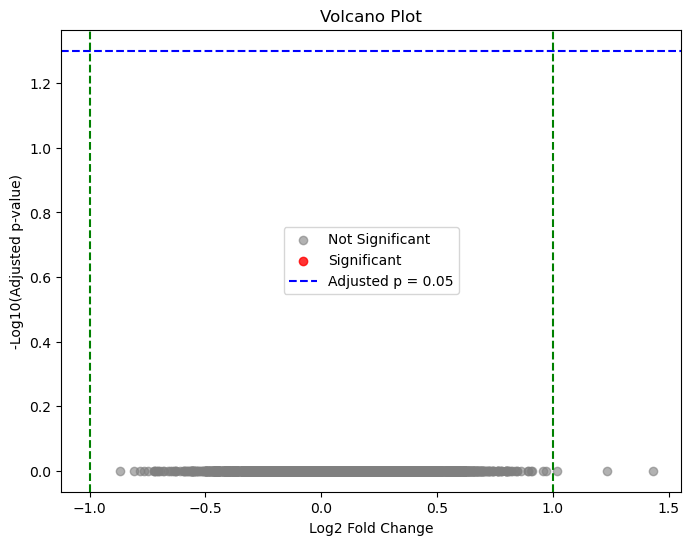

In [65]:
plt.figure(figsize=(8, 6))

# Plot non-significant genes
plt.scatter(
    results_df.loc[
        ~results_df["Significant"],
        "log2_fold_change"
    ],
    results_df.loc[
        ~results_df["Significant"],
        "minus_log10_p"
    ],
    color="gray",
    alpha=0.6,
    label="Not Significant"
)

# Plot significant genes
plt.scatter(
    results_df.loc[
        results_df["Significant"],
        "log2_fold_change"
    ],
    results_df.loc[
        results_df["Significant"],
        "minus_log10_p"
    ],
    color="red",
    alpha=0.8,
    label="Significant"
)

# Threshold lines
plt.axhline(
    y=-np.log10(0.05),
    color="blue",
    linestyle="--",
    label="Adjusted p = 0.05"
)

plt.axvline(x=-1, color="green", linestyle="--")
plt.axvline(x=1, color="green", linestyle="--")

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10(Adjusted p-value)")
plt.title("Volcano Plot")
plt.legend()

plt.savefig("../figures/volcano_plot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Interpretation

- The volcano plot confirms that no differentially expressed genes were identified between the diabetic and control samples after adjusting for multiple comparisons.
- This suggests that the observed differences in gene expression could have occurred by chance rather than representing true biological differences.

### Note

This project uses Welch's t-test followed by the Benjamini–Hochberg (BH) multiple testing correction to calculate adjusted p-values. This workflow is intended for educational purposes to demonstrate the basic concepts of differential gene expression analysis.

In practice, RNA-seq studies commonly use specialized methods such as DESeq2, edgeR, or limma-voom because they are specifically designed for RNA-seq count data and provide more accurate statistical modeling.

### Key Concepts

1. Welch's t-test compares the mean gene expression between diabetic and control groups and calculates a raw p-value for each gene.

2. Benjamini–Hochberg (BH) is a multiple testing correction method that converts raw p-values into adjusted p-values (FDR-adjusted p-values) to reduce false positive results.

3. Genes with an adjusted p-value < 0.05 are considered statistically significant after correcting for multiple comparisons.

#  Final Conclusion

This project demonstrated a complete differential gene expression workflow using Python. Gene expression was compared between diabetic and control samples using Welch's t-test, followed by Benjamini–Hochberg (BH) multiple testing correction to obtain adjusted p-values. Log₂ fold change and a volcano plot were used to visualize the results. No genes were found to be significantly differentially expressed after FDR correction. This project provides a foundation for understanding RNA-seq differential expression analysis before using specialized tools such as DESeq2.